In [2]:
# ============================================
# CELL 1: Setup
# ============================================
!pip install -q rank_bm25 sentence-transformers faiss-cpu nltk matplotlib

import numpy as np
import re
import time
import logging
from typing import List, Dict, Tuple
from dataclasses import dataclass

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger("reranking")

STOPWORDS = set(stopwords.words('english'))

In [3]:
# ============================================
# CELL 2: Reuse corpus + hybrid search engine from previous lesson
# (Slightly expanded corpus so reranking has more to work with)
# ============================================

def preprocess_text(text: str, remove_stopwords: bool = True) -> List[str]:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = word_tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens


corpus = [
    "Our return policy allows customers to send back items within 30 days for a full refund.",
    "If you're unhappy with a purchase, you can request money back within a month of buying it.",
    "Items marked as final sale are not eligible for return or refund under any circumstances.",
    "Machine learning models can automatically detect fraudulent transactions in real time.",
    "AI systems are increasingly used to flag suspicious financial activity as it happens.",
    "Traditional rule-based fraud systems are being replaced by adaptive ML-based approaches.",
    "Employees can request remote work arrangements through the HR portal.",
    "Staff members may apply for work-from-home setups via the internal HR system.",
    "Remote work requests must be approved by a direct manager before taking effect.",
    "Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.",
    "Error code E-4099 means the shipping address failed validation. Check the ZIP code field.",
    "Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse.",
    "Product SKU-88214-B is the wired keyboard model, available in all regions.",
    "Invoice #INV-2024-11837 was issued on March 3rd for account holder J. Martinez.",
    "Invoice #INV-2024-11902 was issued on March 9th for account holder R. Chen.",
    "The company's quarterly earnings report will be released next Thursday.",
    "New office locations are opening in Austin and Denver next quarter.",
    "Refunds are typically processed within 5-7 business days after the return is received.",
]
logger.info(f"Corpus size: {len(corpus)}")
print(f"Corpus size: {len(corpus)}")

Corpus size: 18


In [4]:
# ============================================
# CELL 3: Stage 1 — Hybrid retriever (condensed from previous lesson)
# ============================================

class SparseRetriever:
    def __init__(self, documents: List[str]):
        self.documents = documents
        self.tokenized_docs = [preprocess_text(d) for d in documents]
        self.bm25 = BM25Okapi(self.tokenized_docs)

    def search(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        scores = self.bm25.get_scores(preprocess_text(query))
        ranked_idx = np.argsort(scores)[::-1][:top_k]
        return [(int(i), float(scores[i])) for i in ranked_idx if scores[i] > 0]


class DenseRetriever:
    def __init__(self, documents: List[str], model_name: str = "all-MiniLM-L6-v2"):
        self.documents = documents
        self.model = SentenceTransformer(model_name)
        self.dim = self.model.get_embedding_dimension()
        embeddings = self.model.encode(documents, show_progress_bar=False).astype("float32")
        faiss.normalize_L2(embeddings)
        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)

    def search(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        q_emb = self.model.encode([query]).astype("float32")
        faiss.normalize_L2(q_emb)
        scores, indices = self.index.search(q_emb, top_k)
        return [(int(idx), float(score)) for score, idx in zip(scores[0], indices[0]) if idx != -1]


def hybrid_rrf_search(sparse: SparseRetriever, dense: DenseRetriever, documents: List[str],
                       query: str, top_k: int = 10, candidate_k: int = 30, rrf_k: int = 60) -> List[Tuple[int, float]]:
    """Returns list of (doc_id, rrf_score), ranked descending."""
    sparse_results = sparse.search(query, top_k=candidate_k)
    dense_results = dense.search(query, top_k=candidate_k)
    sparse_ranks = {doc_id: rank + 1 for rank, (doc_id, _) in enumerate(sparse_results)}
    dense_ranks = {doc_id: rank + 1 for rank, (doc_id, _) in enumerate(dense_results)}

    all_ids = set(sparse_ranks) | set(dense_ranks)
    scored = []
    for doc_id in all_ids:
        score = 0.0
        if doc_id in sparse_ranks:
            score += 1.0 / (rrf_k + sparse_ranks[doc_id])
        if doc_id in dense_ranks:
            score += 1.0 / (rrf_k + dense_ranks[doc_id])
        scored.append((doc_id, score))

    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]


sparse_retriever = SparseRetriever(corpus)
dense_retriever = DenseRetriever(corpus)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
# ============================================
# CELL 4: Stage 2 — PRODUCTION RERANKER CLASS
# Wraps a cross-encoder with batching, timing, error handling,
# and truncation-safety checks — structured for real deployment.
# ============================================

class CrossEncoderReranker:
    """
    Production-style reranker wrapper around a HuggingFace cross-encoder.
    Handles batching, latency logging, and truncation warnings.
    """

    def __init__(self, model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2", max_length: int = 512):
        self.model = CrossEncoder(model_name, max_length=max_length)
        self.max_length = max_length
        logger.info(f"Loaded cross-encoder reranker: {model_name}")

    def rerank(self, query: str, candidates: List[Tuple[int, str]], top_k: int = 5) -> List[Dict]:
        """
        candidates: list of (doc_id, document_text)
        Returns: list of dicts sorted by rerank score, descending.
        """
        if not candidates:
            return []

        pairs = [[query, doc_text] for _, doc_text in candidates]

        # Truncation safety check — a real production concern (Pitfall #4)
        for doc_id, doc_text in candidates:
            approx_tokens = len(doc_text.split())
            if approx_tokens > self.max_length * 0.75:  # rough heuristic
                logger.warning(f"doc_id={doc_id} is close to/exceeds max_length; risk of truncation.")

        start = time.time()
        scores = self.model.predict(pairs, batch_size=16, show_progress_bar=False)
        elapsed = time.time() - start
        logger.info(f"Reranked {len(candidates)} candidates in {elapsed*1000:.1f} ms "
                     f"({elapsed*1000/len(candidates):.2f} ms/candidate)")

        results = [
            {"doc_id": doc_id, "document": doc_text, "rerank_score": float(score)}
            for (doc_id, doc_text), score in zip(candidates, scores)
        ]
        results.sort(key=lambda r: r["rerank_score"], reverse=True)
        return results[:top_k]


reranker = CrossEncoderReranker()

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [6]:
# ============================================
# CELL 5: FULL PIPELINE — Hybrid retrieval (Stage 1) -> Reranking (Stage 2)
# ============================================

class TwoStageRAGRetriever:
    """The complete production retrieval pipeline for this lesson."""

    def __init__(self, sparse: SparseRetriever, dense: DenseRetriever, reranker: CrossEncoderReranker, documents: List[str]):
        self.sparse = sparse
        self.dense = dense
        self.reranker = reranker
        self.documents = documents

    def retrieve(self, query: str, stage1_k: int = 15, final_k: int = 5) -> Dict:
        # Stage 1: cheap, wide-recall hybrid search
        stage1_start = time.time()
        stage1_results = hybrid_rrf_search(self.sparse, self.dense, self.documents, query, top_k=stage1_k)
        stage1_time = time.time() - stage1_start

        candidates = [(doc_id, self.documents[doc_id]) for doc_id, _ in stage1_results]

        # Stage 2: expensive, high-precision reranking
        stage2_start = time.time()
        final_results = self.reranker.rerank(query, candidates, top_k=final_k)
        stage2_time = time.time() - stage2_start

        return {
            "query": query,
            "stage1_candidate_count": len(candidates),
            "stage1_latency_ms": stage1_time * 1000,
            "stage2_latency_ms": stage2_time * 1000,
            "stage1_ranking": [self.documents[doc_id] for doc_id, _ in stage1_results[:final_k]],
            "final_ranking": final_results,
        }


pipeline = TwoStageRAGRetriever(sparse_retriever, dense_retriever, reranker, corpus)

In [7]:
# ============================================
# CELL 6: Demonstrate reranking CHANGING the ranking — the core proof
# ============================================

def show_before_after(query: str, stage1_k: int = 15, final_k: int = 5):
    result = pipeline.retrieve(query, stage1_k=stage1_k, final_k=final_k)

    print(f"\n{'='*80}\nQUERY: \"{query}\"\n{'='*80}")
    print(f"Stage 1 (Hybrid RRF) latency: {result['stage1_latency_ms']:.1f} ms | "
          f"Stage 2 (Reranker) latency: {result['stage2_latency_ms']:.1f} ms")

    print(f"\n--- BEFORE reranking (Stage 1 hybrid top-{final_k}) ---")
    for i, doc in enumerate(result["stage1_ranking"], 1):
        print(f"  {i}. {doc}")

    print(f"\n--- AFTER reranking (Stage 2 cross-encoder top-{final_k}) ---")
    for i, r in enumerate(result["final_ranking"], 1):
        print(f"  {i}. [score={r['rerank_score']:.3f}] {r['document']}")

    return result


show_before_after("Can I return this item and get a refund?")
show_before_after("How long do refunds take to process?")
show_before_after("wireless keyboard stock status")


QUERY: "Can I return this item and get a refund?"
Stage 1 (Hybrid RRF) latency: 82.8 ms | Stage 2 (Reranker) latency: 735.4 ms

--- BEFORE reranking (Stage 1 hybrid top-5) ---
  1. Our return policy allows customers to send back items within 30 days for a full refund.
  2. Items marked as final sale are not eligible for return or refund under any circumstances.
  3. Refunds are typically processed within 5-7 business days after the return is received.
  4. If you're unhappy with a purchase, you can request money back within a month of buying it.
  5. Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.

--- AFTER reranking (Stage 2 cross-encoder top-5) ---
  1. [score=5.768] Items marked as final sale are not eligible for return or refund under any circumstances.
  2. [score=4.389] Our return policy allows customers to send back items within 30 days for a full refund.
  3. [score=-0.473] Refunds are typically processed within 5-7 business days 

{'query': 'wireless keyboard stock status',
 'stage1_candidate_count': 15,
 'stage1_latency_ms': 51.914215087890625,
 'stage2_latency_ms': 757.7154636383057,
 'stage1_ranking': ['Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse.',
  'Product SKU-88214-B is the wired keyboard model, available in all regions.',
  "The company's quarterly earnings report will be released next Thursday.",
  'Employees can request remote work arrangements through the HR portal.',
  "If you're unhappy with a purchase, you can request money back within a month of buying it."],
 'final_ranking': [{'doc_id': 11,
   'document': 'Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse.',
   'rerank_score': 5.333345413208008},
  {'doc_id': 12,
   'document': 'Product SKU-88214-B is the wired keyboard model, available in all regions.',
   'rerank_score': -3.308147430419922},
  {'doc_id': 15,
   'document': "The company's quarterly 

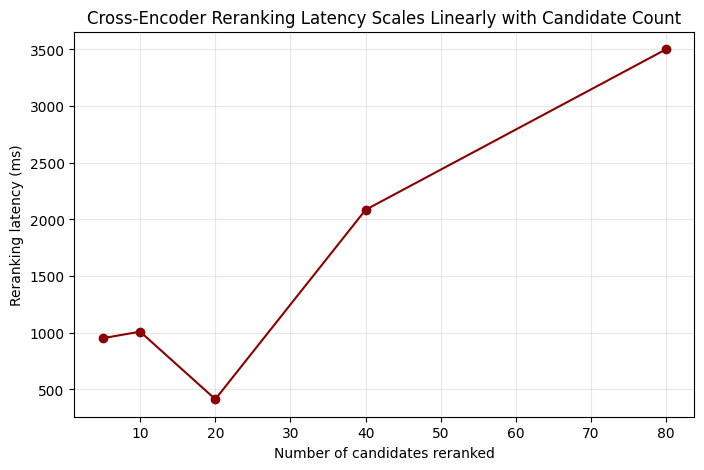

This is exactly why reranking is applied to a SMALL Stage-1 candidate pool,
never the full corpus — the linear scaling makes 'rerank everything' infeasible.


In [8]:
# ============================================
# CELL 7: Quantify latency scaling — proving WHY reranking can't scale to "everything"
# ============================================

import matplotlib.pyplot as plt

candidate_counts = [5, 10, 20, 40, 80]
latencies = []

sample_query = "refund policy for returned items"

for count in candidate_counts:
    stage1_results = hybrid_rrf_search(sparse_retriever, dense_retriever, corpus, sample_query, top_k=min(count, len(corpus)))
    candidates = [(doc_id, corpus[doc_id]) for doc_id, _ in stage1_results]
    # pad candidates by repeating corpus docs if we need more than corpus size, purely to test scaling
    while len(candidates) < count:
        candidates.append(candidates[len(candidates) % len(corpus)])

    start = time.time()
    reranker.rerank(sample_query, candidates[:count], top_k=5)
    elapsed = (time.time() - start) * 1000
    latencies.append(elapsed)

plt.figure(figsize=(8, 5))
plt.plot(candidate_counts, latencies, 'o-', color='darkred')
plt.xlabel("Number of candidates reranked")
plt.ylabel("Reranking latency (ms)")
plt.title("Cross-Encoder Reranking Latency Scales Linearly with Candidate Count")
plt.grid(alpha=0.3)
plt.show()

print("This is exactly why reranking is applied to a SMALL Stage-1 candidate pool,")
print("never the full corpus — the linear scaling makes 'rerank everything' infeasible.")

In [9]:
# ============================================
# CELL 8: Compare two rerankers (quality vs speed trade-off)
# ============================================

reranker_large = CrossEncoderReranker(model_name="cross-encoder/ms-marco-MiniLM-L-12-v2")

test_query = "Can I return this item and get a refund?"
stage1 = hybrid_rrf_search(sparse_retriever, dense_retriever, corpus, test_query, top_k=15)
candidates = [(doc_id, corpus[doc_id]) for doc_id, _ in stage1]

start = time.time()
small_results = reranker.rerank(test_query, candidates, top_k=5)
small_time = (time.time() - start) * 1000

start = time.time()
large_results = reranker_large.rerank(test_query, candidates, top_k=5)
large_time = (time.time() - start) * 1000

print(f"MiniLM-L-6  (small): {small_time:.1f} ms")
print(f"MiniLM-L-12 (large): {large_time:.1f} ms")
print(f"\nTop result — small model:  {small_results[0]['document']}")
print(f"Top result — large model:  {large_results[0]['document']}")
print("\n>> In production, this speed/quality trade-off drives which reranker size you deploy.")

config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  133MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

MiniLM-L-6  (small): 266.3 ms
MiniLM-L-12 (large): 524.2 ms

Top result — small model:  Items marked as final sale are not eligible for return or refund under any circumstances.
Top result — large model:  Our return policy allows customers to send back items within 30 days for a full refund.

>> In production, this speed/quality trade-off drives which reranker size you deploy.
